# Explore dataset structure

In [1]:
from dirs import *
from xflow import TransformRegistry as T
from xflow.utils.io import scan_files
from xflow.utils.sql import merge_sqlite_dbs
from xflow import SqlProvider, PyTorchPipeline, FileProvider
from xflow.data import build_transforms_from_config
from xflow.utils.visualization import plot_image
from xflow.extensions.physics.pipeline import CachedBasisPipeline, IndexCombinator
from xflow.extensions.physics import pattern_gen
from tqdm import tqdm
from copy import deepcopy

from config_utils import load_config, detect_machine
import pandas as pd
import sqlite3
from utils import *

experiment_name = "CLEAR_visualization"  
config = load_config(
    f"{experiment_name}.yaml",
    machine=machine
)

/Users/andrewxu/Documents/GitHub/fiber-image-reconstruction
[config_utils] Using machine profile: mac-andrewxu


# Load dataset

Different with training pipeline, data sample meta data is given

Mainly the run time sythetic dataset need to be compiled and generate here

In [ ]:
"""
Contract:
1. Unify the data format for visualization like (2, N, 1, 256, 256)
   (fiber_input_output_image_type, num_samples, C, H, W)
2. Add labels/colors or class to data samples with index based order matter.
3. Union data samples, labels and colors into three single iterable for downstream visualization.
"""

# ============================================================
# Small helpers
# ============================================================
def make_transforms(parent_dir, base_transform_cfg, drop_last=True):
    """
    Build transforms safely without mutating config["data"]["transforms"]["torch"].
    This fixes the repeated insert bug.
    """
    transform_cfg = [
        {
            "name": "add_parent_dir",
            "params": {"parent_dir": parent_dir},
        },
        *deepcopy(base_transform_cfg),
    ]
    transforms = build_transforms_from_config(transform_cfg)
    return transforms[:-1] if drop_last else transforms


def to_modal_array(x):
    """
    Normalize data to shape (2, N, C, H, W).

    Common cases:
    - list/tuple with length 2, each item (N, C, H, W)
    - ndarray already in shape (2, N, C, H, W)
    - ndarray in shape (N, 2, C, H, W)
    """
    if isinstance(x, np.ndarray):
        arr = x
    else:
        arr = np.stack(x, axis=0)

    if arr.ndim != 5:
        raise ValueError(f"Expected ndim=5, got shape={arr.shape}")

    if arr.shape[0] == 2:
        return arr

    if arr.shape[1] == 2:
        return np.transpose(arr, (1, 0, 2, 3, 4))

    raise ValueError(f"Cannot convert to (2, N, C, H, W), got shape={arr.shape}")


def build_sql_provider(db_path, sql, subsample_n=None, seed=None):
    provider = SqlProvider(
        sources={"connection": db_path, "sql": sql},
        output_config={"list": "image_path"},
    )
    if subsample_n is not None:
        provider = provider.subsample(n_samples=subsample_n, seed=seed)
    return provider


def load_sql_pipeline(db_path, sql, parent_dir, *, subsample_n=None):
    """
    Standard SQL -> PyTorchPipeline -> numpy -> (2, N, C, H, W)
    """
    provider = build_sql_provider(
        db_path=db_path,
        sql=sql,
        subsample_n=subsample_n,
        seed=config["seed"],
    )
    transforms = make_transforms(
        parent_dir=parent_dir,
        base_transform_cfg=config["data"]["transforms"]["torch"],
        drop_last=True,
    )
    pipeline = PyTorchPipeline(provider, transforms).to_numpy()
    return to_modal_array(pipeline)

def load_files_pipeline(root_dir, subsample_n=None, extensions=None):
    provider = FileProvider(
    root_paths=root_dir,
    extensions=extensions, # None = all files
    path_type="string", # return paths as strings
    )
    if subsample_n is not None:
        provider = provider.subsample(n_samples=subsample_n, seed=config["seed"])
    transforms = make_transforms(
        parent_dir=root_dir,
        base_transform_cfg=config["data"]["transforms"]["torch"],
        drop_last=True,
    )

    pipeline = PyTorchPipeline(provider, transforms).to_numpy()
    return to_modal_array(pipeline)
    

def make_bundle(samples, label, color, name=None):
    """
    samples: (2, N, C, H, W)
    """
    n = samples.shape[1]
    return {
        "name": name,
        "samples": samples,
        "labels": [label] * n,
        "colors": [color] * n,
    }


def concat_bundles(*bundles, name="merged"):
    """
    Concatenate multiple bundles along sample axis.
    """
    samples = np.concatenate([b["samples"] for b in bundles], axis=1)
    labels = sum([b["labels"] for b in bundles], [])
    colors = sum([b["colors"] for b in bundles], [])
    return {
        "name": name,
        "samples": samples,
        "labels": labels,
        "colors": colors,
    }


def build_sgm_stream():
    """
    Reused by DMD synthetic builders.
    """
    canvas = pattern_gen.DynamicPatterns(*config["simulation"]["canvas_size"])
    canvas.set_postprocess_fns(
        build_transforms_from_config(config["simulation"]["process_functions"])
    )
    canvas._distributions = [
        pattern_gen.StaticGaussianDistribution(canvas)
        for _ in range(config["simulation"]["total_Guassian_num"])
    ]
    canvas.set_threshold(config["simulation"]["minimum_pixel_threshold"])

    stream = canvas.pattern_stream(
        std_1=config["simulation"]["std_1"],
        std_2=config["simulation"]["std_2"],
        max_intensity=config["simulation"]["max_intensity"],
        fade_rate=config["simulation"]["fade_rate"],
        distribution=config["simulation"]["distribution"],
    )
    return stream


def build_dmd_syth_plus_eval(
    db_path,
    extracted_dir,
    orth_sql,
    eval_sql,
    syth_label,
    eval_label,
    syth_color,
    eval_color,
    syth_take_n=1000,
):
    """
    DMD orthogonal basis + synthetic augmentation + eval set
    """
    # ---------- eval ----------
    eval_provider = build_sql_provider(db_path, eval_sql)
    eval_transforms = make_transforms(
        parent_dir=extracted_dir,
        base_transform_cfg=config["data"]["transforms"]["torch"],
        drop_last=True,
    )
    eval_pipeline = PyTorchPipeline(eval_provider, eval_transforms).to_numpy()
    eval_samples = to_modal_array(eval_pipeline)

    # ---------- synthetic ----------
    orth_provider = build_sql_provider(db_path, orth_sql)

    full_transforms = make_transforms(
        parent_dir=extracted_dir,
        base_transform_cfg=config["data"]["transforms"]["torch"],
        drop_last=False,
    )

    combinator = IndexCombinator(
        pattern_provider=build_sgm_stream(),
        transforms=build_transforms_from_config(config["combinator"]["transforms"]["torch"]),
    )

    train_dataset = CachedBasisPipeline(
        orth_provider,
        combinator=combinator,
        transforms=full_transforms,
        num_samples=config["data"]["total_train_samples"],
        seed=config["seed"],
        eager=True,
    )

    # Important fix:
    # do not call next(iter(train_dataset)) each time
    iterator = iter(train_dataset)

    samples = []
    for _ in tqdm(range(syth_take_n)):
        samples.append(next(iterator))

    samples = np.stack(samples, axis=0)              # (N, 2, C, H, W)
    samples = np.transpose(samples, (1, 0, 2, 3, 4))  # (2, N, C, H, W)

    # ---------- merge ----------
    bundle_syth = make_bundle(samples, syth_label, syth_color)
    bundle_eval = make_bundle(eval_samples, eval_label, eval_color)

    return concat_bundles(bundle_syth, bundle_eval)


# ============================================================
# Dataset builders
# Keep this flat and readable
# ============================================================
def build_dmd_only():
    return build_dmd_syth_plus_eval(
        db_path=dirs["DMD_only"]["dataset_db_dir"],
        extracted_dir=dirs["DMD_only"]["dataset_extracted_dir"],
        orth_sql=config["sql"]["train"],
        eval_sql=config["sql"]["eval"],
        syth_label="DMD_syth",
        eval_label="DMD_val",
        syth_color="#636EFA",
        eval_color="#E6C243",
        syth_take_n=1000,
    )


def build_chromox():
    samples = load_sql_pipeline(
        db_path=config["paths"]["processed_chromox"] +config["dataset_structure"]["db"],
        sql=config["sql"]["chromox_all"],
        parent_dir=config["paths"]["processed_chromox"],
        subsample_n=1000,
    )
    return make_bundle(samples, r"$e^{-}$ Chromox", "#EF553B", name="chromox")


def build_yag():
    samples = load_sql_pipeline(
        db_path=config["paths"]["processed_yag"] +config["dataset_structure"]["db"],
        sql=config["sql"]["yag_all"],
        parent_dir=config["paths"]["processed_yag"],
        subsample_n=1000,
    )
    return make_bundle(samples, r"$e^{-}$ Yag", "#00CC96", name="yag")


def build_chromox_laser():
    samples = load_sql_pipeline(
        db_path=config["paths"]["processed_chromox_laser"] +config["dataset_structure"]["db"],
        sql=config["sql"]["chromox_laser"],
        parent_dir=config["paths"]["processed_chromox_laser"],
        subsample_n=1000,
    )
    return make_bundle(samples, "laser on Chromox", "#FFA15A", name="chromox_laser")


def build_yag_laser():
    samples = load_sql_pipeline(
        db_path=config["paths"]["processed_yag_laser"] +config["dataset_structure"]["db"],
        sql=config["sql"]["yag_laser"],
        parent_dir=config["paths"]["processed_yag_laser"],
        subsample_n=1000,
    )
    return make_bundle(samples, "laser on Yag", "#B6E880", name="yag_laser")

def build_dmd_orth_basis():
    orth_provider = build_sql_provider(
        db_path=dirs["DMD_lab"]["dataset_db_dir"],
        sql=config["sql"]["lab_dmd_orth"],
        subsample_n=1000,
        seed=config["seed"],
    )
    transforms = make_transforms(
        parent_dir=dirs["DMD_lab"]["dataset_extracted_dir"],
        base_transform_cfg=config["data"]["transforms"]["torch"],
        drop_last=True,
    )
    pipeline = PyTorchPipeline(orth_provider, transforms).to_numpy()
    samples = to_modal_array(pipeline)
    return make_bundle(samples, "DMD Orth", "#D53B2A", name="dmd_orth_basis")


def build_dmd_lab():
    return build_dmd_syth_plus_eval(
        db_path=dirs["DMD_lab"]["dataset_db_dir"],
        extracted_dir=dirs["DMD_lab"]["dataset_extracted_dir"],
        orth_sql=config["sql"]["lab_dmd_orth"],
        eval_sql=config["sql"]["lab_dmd_eval"],
        syth_label="DMD_syth - lab",
        eval_label="DMD_val - lab",
        syth_color="#11B2DF",
        eval_color="#EF1717",
        syth_take_n=1000,
    )


def build_dmd_cockcroft():
    train_samples = load_sql_pipeline(
        db_path=dirs["DMD_cockcroft"]["dataset_db_dir"],
        sql=config["sql"]["cockcroft_dmd_train"],
        parent_dir=dirs["DMD_cockcroft"]["dataset_extracted_dir"],
        subsample_n=5000,
    )
    eval_samples = load_sql_pipeline(
        db_path=dirs["DMD_cockcroft"]["dataset_db_dir"],
        sql=config["sql"]["cockcroft_dmd_eval"],
        parent_dir=dirs["DMD_cockcroft"]["dataset_extracted_dir"],
        subsample_n=1000,
    )

    bundle_train = make_bundle(train_samples, "DMD Cockcroft train", "#11B2DF")
    bundle_eval = make_bundle(eval_samples, "DMD Cockcroft eval", "#EF1717")
    return concat_bundles(bundle_train, bundle_eval, name="dmd_cockcroft")


def build_clear_2022():
    samples = load_files_pipeline(
    root_dir=config["paths"]["clear_2022"],
    subsample_n=1000,
    extensions=[".png", ".jpg", ".jpeg", ".tif", ".tiff"], # or None for all files
    )
    return make_bundle(samples, r"$e^{-}$ Chromox", "#EF553B", name="clear_2022")


def build_chromox_line_scan():
    samples = load_sql_pipeline(
        db_path=config["paths"]["processed_chromox"] +config["dataset_structure"]["db"],
        sql=config["sql"]["chromox_line_scan"],
        parent_dir=config["paths"]["processed_chromox"],
        subsample_n=2000,
    )
    return make_bundle(samples, r"$e^{-}$ Chromox Line Scan", "#58B828", name="chromox_line_scan")


def build_chromox_random_scan():
    samples = load_sql_pipeline(
        db_path=config["paths"]["processed_chromox"] +config["dataset_structure"]["db"],
        sql=config["sql"]["chromox_random_scan"],
        parent_dir=config["paths"]["processed_chromox"],
        subsample_n=1000,
    )
    return make_bundle(samples, r"$e^{-}$ Chromox Random Scan", "#F0E625", name="chromox_random_scan")


# ============================================================
# Select what to build here
# ============================================================
DATASET_BUILDERS = {
    "dmd_only": build_dmd_only,
    "chromox": build_chromox,
    "chromox_line_scan": build_chromox_line_scan,
    "chromox_random_scan": build_chromox_random_scan,
    "chromox_laser": build_chromox_laser,
    "yag": build_yag,
    "yag_laser": build_yag_laser,
    "dmd_lab": build_dmd_lab,
    "dmd_cockcroft": build_dmd_cockcroft,
    "dmd_orth_basis": build_dmd_orth_basis,
    "clear_2022": build_clear_2022,

}

selected_names = [
    # "clear_2022",
    # "yag",
    # "yag_laser",
    # "chromox_laser",
    # "chromox_line_scan",
    # "chromox_random_scan",
    "dmd_only",
    # "dmd_lab",
    "dmd_orth_basis",
]

bundles = {}
for name in selected_names:
    if name not in DATASET_BUILDERS:
        raise KeyError(f"Unknown dataset name: {name}")
    bundles[name] = DATASET_BUILDERS[name]()


# ============================================================
# Merge selected datasets in the given order
# ============================================================
selected_bundles = [bundles[name] for name in selected_names]
merged = concat_bundles(*selected_bundles, name="merged")

all_samples = merged["samples"]   # (2, N_total, C, H, W)
all_labels = merged["labels"]     # len = N_total
all_colors = merged["colors"]     # len = N_total


# Optional:
# downstream single iterable, each item is:
#   sample_pair: (2, C, H, W)
#   label: str
#   color: str
downstream_iterable = list(zip(np.moveaxis(all_samples, 1, 0), all_labels, all_colors))


# ============================================================
# Example visual checks
# ============================================================
if "dmd_lab" in bundles:
    plot_image(bundles["dmd_lab"]["samples"][1][0])

if "chromox_line_scan" in bundles:
    plot_image(bundles["chromox_line_scan"]["samples"][1][99])

if "chromox_random_scan" in bundles:
    plot_image(bundles["chromox_random_scan"]["samples"][1][528])

In [ ]:
# ============================
# Chromox laser data augmentation through linear combination
# ============================






# ============================
# Yag laser data augmentation through linear combination
# ============================







# Latent space distribution

In [ ]:
import numpy as np
import imageio.v2 as imageio
from pathlib import Path
from xflow.utils.visualization import DimReducer, Embedding3DPlot


def embed_images(images, final_method="umap", final_dim=2, random_state=42):
    X = np.asarray(images, dtype=np.float32)
    X = X.reshape(X.shape[0], -1)

    # current behavior: normalize globally
    X /= (X.max() + 1e-12)

    method_norm = "".join(ch for ch in str(final_method).lower() if ch.isalnum())

    if method_norm == "pca":
        pca = DimReducer("pca", n_components=final_dim, random_state=random_state)
        X_final = pca.fit_transform(X)
        return X_final, pca, None

    pca = DimReducer("pca", n_components=min(50, X.shape[1]), random_state=random_state)
    X50 = pca.fit_transform(X)

    if method_norm == "tsne":
        final = DimReducer(
            "tsne",
            n_components=final_dim,
            random_state=random_state,
        )
    elif method_norm == "umap":
        final = DimReducer(
            "umap",
            n_components=final_dim,
            random_state=random_state,
            n_neighbors=10,
            min_dist=0.8,
            metric="euclidean",
        )
    else:
        raise ValueError(f"Unsupported final_method: {final_method}")

    Z = final.fit_transform(X50)
    return Z, pca, final


def prepare_group_data(bundles, selected_names, index):
    """
    Convert bundles -> group_data for selected datasets.

    bundles[name]["samples"]: (2, N, C, H, W)
    """
    group_data = {}

    for name in selected_names:
        if name not in bundles:
            continue

        samples = bundles[name]["samples"][index]   # (N, C, H, W)
        labels = bundles[name]["labels"]
        colors = bundles[name]["colors"]

        group_data[name] = (samples, labels, colors)

    return group_data


def flatten_group_data(group_data, selected_names=None):
    """
    Flatten selected groups into one images / labels / colors set.
    """
    if selected_names is None:
        selected_names = list(group_data.keys())
    else:
        selected_names = [k for k in selected_names if k in group_data]

    if len(selected_names) == 0:
        raise ValueError("No valid dataset selected.")

    images = np.concatenate([group_data[k][0] for k in selected_names], axis=0)
    labels = [label for k in selected_names for label in group_data[k][1]]
    colors = [c for k in selected_names for c in group_data[k][2]]

    return images, labels, colors, selected_names


# ============================================================
# Example usage
# ============================================================
index = 0  # 0: fiber output speckle, 1: original image

selected_names = [
    # "chromox_line_scan",
    # "chromox_random_scan",
    # "chromox_laser",
    # "clear_2022",
    # "yag",
    # "yag_laser",
    # "dmd_lab",
    "dmd_only",
    "dmd_orth_basis",
]

group_data = prepare_group_data(bundles, selected_names, index)
images, labels, colors, used_names = flatten_group_data(group_data, selected_names)

for method in ["t-SNE", "UMAP"]:  # "t-SNE", "UMAP", "PCA"
    coords, pca_model, final_model = embed_images(
        images,
        final_method=method,
        final_dim=3,
        random_state=42,
    )

    title = f"{method.upper()} projection - {'MMF output speckle' if index == 0 else 'Original images'}"

    plotter = Embedding3DPlot(
        coords=coords,
        labels=labels,
        title=title,
        point_size=2,
        color=colors,
        show_projections=False,
        projection_envelope=True,
        projection_alpha=0.25,
        projection_size_scale=0.7,
        projection_gap_ratio=0.06,
        projection_envelope_alpha=0.18,
    )

    plotter.set_style("darkmode")

    out_dir = Path("results/gif")
    out_dir.mkdir(parents=True, exist_ok=True)

    frames = []
    n_frames = 120
    base_elev, base_azim = 25.0, 40.0
    azim_radius = 25.0 / 2.0
    elev_radius = 10.0 / 2.0
    t = np.linspace(0, 2 * np.pi, n_frames, endpoint=False)

    for tt in t:
        azim = base_azim + azim_radius * np.cos(tt)
        elev = base_elev + elev_radius * np.sin(tt)

        frame = plotter.get_matplotlib_frame(
            elev=float(elev),
            azim=float(azim),
            dpi=120,
        )
        frames.append(frame)

    safe_name = "_".join(used_names)
    imageio.mimsave(
        out_dir / f"embedding_orbit_loop_{method}_{safe_name}.gif",
        frames,
        fps=50,
        loop=0,
    )
    plotter.close()

# Chromox based linear combination data augmentation

# Fiber coupling rate vs time

In [ ]:
# ============================
# Merge entire CLEAR 2025 dataset in to a single database
# ============================
db_paths = scan_files(dirs["processed_db_dir"], extensions=[".db"], return_type="str")
conn = merge_sqlite_dbs(db_paths, source_column="db_path")
sql = """
SELECT *
FROM mmf_dataset_metadata
"""
tables_df = pd.read_sql_query(sql, conn)
conn.close()
# optional: drop duplicate column names (e.g. both tables have "id", "db_path")
tables_df = tables_df.loc[:, ~tables_df.columns.duplicated()]
print(tables_df.shape)
tables_df.head()

In [ ]:
from datetime import datetime
import numpy as np
import matplotlib.pyplot as plt

# Minimal inputs from your dataframe
timestamps = tables_df["image_id"].astype(np.int64).tolist()
coupling_ratio = tables_df["coupling_ratio"].astype(float).tolist()
classes = tables_df["image_device"].tolist()

def plot_coupling_time_series(timestamps, coupling_ratio, classes, dot_size=50):
    time_labels = [datetime.fromtimestamp(ts / 1e9).strftime("%Y-%m-%d %H:%M") for ts in timestamps]
    x_indices = list(range(len(coupling_ratio)))

    plt.figure(figsize=(10, 5))

    # 3rd-degree polynomial trend
    z = np.polyfit(x_indices, coupling_ratio, 3)
    p = np.poly1d(z)
    # plt.plot(x_indices, p(x_indices), color="red", dashes=(5, 5), linewidth=1, label="Overall Trend", zorder=3)

    custom_colors = ["C1", "C2", "C0"]
    unique_classes = sorted(set(classes))

    for i, cls in enumerate(unique_classes):
        cls_x = [x_indices[j] for j, c in enumerate(classes) if c == cls]
        cls_y = [coupling_ratio[j] for j, c in enumerate(classes) if c == cls]
        plt.scatter(cls_x, cls_y, label=cls, s=dot_size, color=custom_colors[i % len(custom_colors)], zorder=2)

    step = max(1, len(x_indices) // 10)
    tick_positions = x_indices[::step]
    plt.xticks(tick_positions, [time_labels[i] for i in tick_positions], rotation=15, ha="right")

    plt.xlabel("Time (Sequential)")
    plt.ylabel("Coupling Ratio")
    plt.title("Coupling Ratio vs Time")
    plt.legend()
    plt.grid(True, alpha=0.4)
    plt.tight_layout()
    plt.show()

plot_coupling_time_series(timestamps, coupling_ratio, classes, dot_size=1)

# Image file size change vs time

In [ ]:
sql = """
SELECT
    d.*,
    c.experiment_description,
    c.image_source,
    c.image_device,
    c.fiber_config,
    c.camera_config,
    c.other_config
FROM mmf_dataset_metadata AS d
LEFT JOIN mmf_experiment_config AS c
  ON c.id = d.config_id
 AND c.db_path = d.db_path;
"""

with sqlite3.connect(str(dirs["merged_db_path"])) as con:
    tables_df = pd.read_sql_query(sql, con)

In [ ]:

from pathlib import Path
import matplotlib.pyplot as plt
from datetime import datetime


temp = [
    (Path(db).parent.parent / img).as_posix()
    for db, img in zip(tables_df["db_path"], tables_df["image_path"])
]

sizes_kb = [os.path.getsize(path) / 1024 for path in temp]
timestamps = tables_df['image_id'].astype(int).tolist()  # Assuming image_id is a timestamp in seconds
classes = tables_df["image_device"].tolist()  # Assuming "image_device" is the class label

def plot_compressed_time_series(timestamps, sizes_kb, classes, dot_size=50):
    time_labels = [datetime.fromtimestamp(ts / 1e9).strftime('%Y-%m-%d %H:%M') for ts in timestamps]
    x_indices = list(range(len(sizes_kb)))
    
    plt.figure(figsize=(10, 5))
    
    # Fit a 3rd-degree polynomial trend curve across all data points
    z = np.polyfit(x_indices, sizes_kb, 3)
    p = np.poly1d(z)
    plt.plot(x_indices, p(x_indices), color='red', dashes=(5, 5), linewidth=1, label='Overall Trend', zorder=3)
    
    # Define specific colors and sort classes for consistent assignment
    custom_colors = ['C1', 'C2', 'C0']
    unique_classes = sorted(list(set(classes)))
    
    for i, cls in enumerate(unique_classes):
        cls_x = [x_indices[j] for j, c in enumerate(classes) if c == cls]
        cls_y = [sizes_kb[j] for j, c in enumerate(classes) if c == cls]
        
        # Select color, wrapping around if there are more than 3 classes
        color = custom_colors[i % len(custom_colors)]
        
        plt.scatter(cls_x, cls_y, label=cls, s=dot_size, color=color, zorder=2)
    
    # Sample the X-axis ticks
    step = max(1, len(x_indices) // 10)
    tick_positions = x_indices[::step]
    selected_labels = [time_labels[i] for i in tick_positions]
    
    # Apply manual rotation and alignment
    plt.xticks(tick_positions, selected_labels, rotation=15, ha='right')
    
    plt.xlabel('Time (Sequential)')
    plt.ylabel('File Size (KB)')
    plt.title('File Size vs Time')
    
    plt.legend() 
    plt.grid(True, alpha=0.4)
    plt.tight_layout()
    
    plt.show()

# Example call:
plot_compressed_time_series(timestamps, sizes_kb, classes, dot_size=1)

# Check Abnormal samples

## Coupling ratio too big or too small samples plot
select some sample where CR smaller than 30 or bigger than 300 for inspection

## Staturation
Select and plot some saturated samples for inspection

# Other interesting samples

# Check if dataset distribution is correct/as expected 
With direct image pixelwise stacking (display in log scale) or with MIP (maximum intensity projection)

In [ ]:
from xflow.utils.visualization import plot_image, stack_mip

data_type = "processed_chromox_cropped"  # chromox_random_scan  chromox_line_scan  yag_random_scan  yag_line_scan  processed_chromox_cropped

if data_type == "chromox_laser":
    provider_path = config["paths"]["processed_chromox_laser"]
elif data_type == "yag_laser":
    provider_path = config["paths"]["processed_yag_laser"]
elif data_type.startswith("chromox"):
    provider_path = config["paths"]["processed_chromox"]
elif data_type.startswith("yag"):
    provider_path = config["paths"]["processed_yag"]
elif data_type.startswith("train"):
    provider_path = config["paths"]["processed_dmd"]
elif data_type.startswith("processed_chromox_cropped"):
    provider_path = config["paths"]["processed_chromox_cropped"]
else:
    raise ValueError(f"Unknown data_type: {data_type}")

provider_db_path = provider_path + config["dataset_structure"]["db"]

provider = SqlProvider(
    sources={"connection": provider_db_path, "sql": config["sql"][data_type]},   
    output_config={'list': "image_path"}
)#.subsample(n_samples=10000, seed=config["seed"])

config["data"]["transforms"]["torch"].insert(0, {
    "name": "add_parent_dir",
    "params": {
        "parent_dir": provider_path
    }
})
transforms = build_transforms_from_config(config["data"]["transforms"]["torch"])

data_pipeline = PyTorchPipeline(
    provider, 
    transforms[:-1],
).to_numpy() 


mip = stack_mip(data_pipeline[1])
plot_image(mip, title="MIP of {}".format(data_type), cmap="inferno", scale="linear") # inferno, viridis, plasma, magma, gray

# Chromox line scans visualization

In [ ]:
from xflow.utils.visualization import plot_image, stack_mip

sql_0 = """
    SELECT image_path
    FROM mmf_dataset_metadata
    WHERE purpose = 'testset'
      AND is_saturated_ground_truth = 0
      AND CAST(json_extract(camera_config, '$.ground_truth_camera_exposure') AS REAL) = 195000
      AND CAST(json_extract(camera_config, '$.ground_truth_camera_gain') AS INTEGER) = 0
      AND CAST(json_extract(camera_config, '$.speckle_camera_exposure') AS REAL) = 195000
      AND CAST(json_extract(camera_config, '$.speckle_camera_gain') AS INTEGER) = 0;
"""

sql_1 = """
    SELECT image_path
    FROM mmf_dataset_metadata
    WHERE purpose = 'real beam orthogonal acquisition'
      AND comments = 'CLEAR beamtime; 10Hz repetition rate; 15 bunches; ND filter 3; '
      AND is_saturated_ground_truth = 0
      AND CAST(json_extract(camera_config, '$.ground_truth_camera_exposure') AS REAL) = 195000
      AND CAST(json_extract(camera_config, '$.ground_truth_camera_gain') AS INTEGER) = 0
      AND CAST(json_extract(camera_config, '$.speckle_camera_exposure') AS REAL) = 195000
      AND CAST(json_extract(camera_config, '$.speckle_camera_gain') AS INTEGER) = 0;
"""

POSITION = 4  # 0 = 1st in group, 1 = 2nd, ..., 4 = 5th
sql_2 = f"""
WITH ordered AS (
    SELECT
        image_path,
        ROW_NUMBER() OVER (ORDER BY image_path) - 1 AS rn
    FROM mmf_dataset_metadata
    WHERE purpose = 'real beam orthogonal acquisition'
      AND comments = 'CLEAR beamtime; 10Hz repetition rate; 15 bunches; ND filter 3; '
      AND is_saturated_ground_truth = 0
      AND CAST(json_extract(camera_config, '$.ground_truth_camera_exposure') AS REAL) = 195000
      AND CAST(json_extract(camera_config, '$.ground_truth_camera_gain') AS INTEGER) = 0
      AND CAST(json_extract(camera_config, '$.speckle_camera_exposure') AS REAL) = 195000
      AND CAST(json_extract(camera_config, '$.speckle_camera_gain') AS INTEGER) = 0
)
SELECT image_path
FROM ordered
WHERE rn % 5 = {POSITION};
"""

# select training set building blocks. select from only the last three groups, and fliter out the boundary cases.
GT_SUM_MIN = 36000  # keep rows with ground_truth_stats_sum >= this value   good value 36000

sql_3 = f"""
WITH ordered AS (
    SELECT
        image_path,
        ROW_NUMBER() OVER (ORDER BY image_path) - 1 AS rn,
        CAST(json_extract(REPLACE(ground_truth_stats, char(39), '"'), '$.sum') AS REAL) AS gt_sum
    FROM mmf_dataset_metadata
    WHERE purpose = 'real beam orthogonal acquisition'
      AND comments = 'CLEAR beamtime; 10Hz repetition rate; 15 bunches; ND filter 3; '
      AND is_saturated_ground_truth = 0
      AND CAST(json_extract(camera_config, '$.ground_truth_camera_exposure') AS REAL) = 195000
      AND CAST(json_extract(camera_config, '$.ground_truth_camera_gain') AS INTEGER) = 0
      AND CAST(json_extract(camera_config, '$.speckle_camera_exposure') AS REAL) = 195000
      AND CAST(json_extract(camera_config, '$.speckle_camera_gain') AS INTEGER) = 0
),
candidates AS (
    SELECT
        image_path,
        rn,
        CAST(rn / 5 AS INTEGER) AS grp_id,
        (rn % 5) AS pos_in_grp,
        gt_sum
    FROM ordered
    WHERE (rn % 5) IN (2, 3, 4)
      AND gt_sum IS NOT NULL
      AND gt_sum >= {GT_SUM_MIN}
),
paired AS (
    -- keep only groups where 2,3,4 all survive threshold
    SELECT *
    FROM candidates
    WHERE grp_id IN (
        SELECT grp_id
        FROM candidates
        GROUP BY grp_id
        HAVING COUNT(*) = 3
    )
),
winner AS (
    SELECT
        *,
        ROW_NUMBER() OVER (
            PARTITION BY grp_id
            ORDER BY gt_sum DESC, pos_in_grp DESC
        ) AS pick_rank
    FROM paired
)
SELECT
    image_path,
    gt_sum,
    grp_id,
    pos_in_grp
FROM winner
WHERE pick_rank = 1
ORDER BY grp_id;
"""



# select test set, same logic
GT_SUM_MIN = 36000  # keep rows with ground_truth_stats_sum >= this value   good value 36000

sql_4 = f"""
WITH ordered AS (
    SELECT
        image_path,
        ROW_NUMBER() OVER (ORDER BY image_path) - 1 AS rn,
        CAST(json_extract(REPLACE(ground_truth_stats, char(39), '"'), '$.sum') AS REAL) AS gt_sum
    FROM mmf_dataset_metadata
    WHERE purpose = 'testset'
      AND is_saturated_ground_truth = 0
      AND CAST(json_extract(camera_config, '$.ground_truth_camera_exposure') AS REAL) = 195000
      AND CAST(json_extract(camera_config, '$.ground_truth_camera_gain') AS INTEGER) = 0
      AND CAST(json_extract(camera_config, '$.speckle_camera_exposure') AS REAL) = 195000
      AND CAST(json_extract(camera_config, '$.speckle_camera_gain') AS INTEGER) = 0
),
candidates AS (
    SELECT
        image_path,
        rn,
        CAST(rn / 5 AS INTEGER) AS grp_id,
        (rn % 5) AS pos_in_grp,
        gt_sum
    FROM ordered
    WHERE (rn % 5) IN (2, 3, 4)
      AND gt_sum IS NOT NULL
      AND gt_sum >= {GT_SUM_MIN}
),
paired AS (
    -- keep only groups where 2,3,4 all survive threshold
    SELECT *
    FROM candidates
    WHERE grp_id IN (
        SELECT grp_id
        FROM candidates
        GROUP BY grp_id
        HAVING COUNT(*) = 3
    )
),
winner AS (
    SELECT
        *,
        ROW_NUMBER() OVER (
            PARTITION BY grp_id
            ORDER BY gt_sum DESC, pos_in_grp DESC
        ) AS pick_rank
    FROM paired
)
SELECT
    image_path,
    gt_sum,
    grp_id,
    pos_in_grp
FROM winner
WHERE pick_rank = 1
ORDER BY grp_id;
"""



# sample from the selected training set with a certain stride (e.g. keep 1 out of 3)
GT_SUM_MIN = 36000
STRIDE = 0 # 0 = keep all, 1 = keep every other, 2 = keep 1 out of 3, etc.

sql_5 = f"""
WITH ordered AS (
    SELECT
        image_id,
        image_path,
        ROW_NUMBER() OVER (ORDER BY CAST(image_id AS INTEGER) ASC) - 1 AS rn,
        CAST(json_extract(REPLACE(ground_truth_stats, char(39), '"'), '$.sum') AS REAL) AS gt_sum
    FROM mmf_dataset_metadata
    WHERE purpose = 'real beam orthogonal acquisition'
      AND comments = 'CLEAR beamtime; 10Hz repetition rate; 15 bunches; ND filter 3; '
      AND is_saturated_ground_truth = 0
      AND CAST(json_extract(camera_config, '$.ground_truth_camera_exposure') AS REAL) = 195000
      AND CAST(json_extract(camera_config, '$.ground_truth_camera_gain') AS INTEGER) = 0
      AND CAST(json_extract(camera_config, '$.speckle_camera_exposure') AS REAL) = 195000
      AND CAST(json_extract(camera_config, '$.speckle_camera_gain') AS INTEGER) = 0
),
candidates AS (
    SELECT
        image_id,
        image_path,
        rn,
        CAST(rn / 5 AS INTEGER) AS grp_id,
        (rn % 5) AS pos_in_grp,
        gt_sum
    FROM ordered
    WHERE (rn % 5) IN (2, 3, 4)
      AND gt_sum IS NOT NULL
      AND gt_sum >= {GT_SUM_MIN}
),
paired AS (
    SELECT *
    FROM candidates
    WHERE grp_id IN (
        SELECT grp_id
        FROM candidates
        GROUP BY grp_id
        HAVING COUNT(*) = 3
    )
),
winner AS (
    SELECT
        *,
        ROW_NUMBER() OVER (
            PARTITION BY grp_id
            ORDER BY gt_sum DESC, pos_in_grp DESC
        ) AS pick_rank
    FROM paired
),
final_sorted AS (
    SELECT
        image_id,
        image_path,
        gt_sum,
        grp_id,
        pos_in_grp,
        ROW_NUMBER() OVER (ORDER BY CAST(image_id AS INTEGER) ASC) - 1 AS out_idx
    FROM winner
    WHERE pick_rank = 1
)
SELECT
    image_id,
    image_path,
    gt_sum,
    grp_id,
    pos_in_grp
FROM final_sorted
WHERE out_idx % ({STRIDE} + 1) = 0
ORDER BY CAST(image_id AS INTEGER) ASC;
"""


# similar to above, but random sample with a certain ratio instead of fixed stride. e.g. 0.5 means keep 50% of the data, randomly selected.
GT_SUM_MIN = 36000
SAMPLE_RATIO = 0.3  # 0.0 to 1.0 (1.0 = 100%)

sql_6 = f"""
WITH ordered AS (
    SELECT
        image_path,
        ROW_NUMBER() OVER (ORDER BY image_path) - 1 AS rn,
        CAST(json_extract(REPLACE(ground_truth_stats, char(39), '"'), '$.sum') AS REAL) AS gt_sum
    FROM mmf_dataset_metadata
    WHERE purpose = 'real beam orthogonal acquisition'
      AND comments = 'CLEAR beamtime; 10Hz repetition rate; 15 bunches; ND filter 3; '
      AND is_saturated_ground_truth = 0
      AND CAST(json_extract(camera_config, '$.ground_truth_camera_exposure') AS REAL) = 195000
      AND CAST(json_extract(camera_config, '$.ground_truth_camera_gain') AS INTEGER) = 0
      AND CAST(json_extract(camera_config, '$.speckle_camera_exposure') AS REAL) = 195000
      AND CAST(json_extract(camera_config, '$.speckle_camera_gain') AS INTEGER) = 0
),
candidates AS (
    SELECT
        image_path,
        rn,
        CAST(rn / 5 AS INTEGER) AS grp_id,
        (rn % 5) AS pos_in_grp,
        gt_sum
    FROM ordered
    WHERE (rn % 5) IN (2, 3, 4)
      AND gt_sum IS NOT NULL
      AND gt_sum >= {GT_SUM_MIN}
),
paired AS (
    SELECT *
    FROM candidates
    WHERE grp_id IN (
        SELECT grp_id
        FROM candidates
        GROUP BY grp_id
        HAVING COUNT(*) = 3
    )
),
winner AS (
    SELECT
        *,
        ROW_NUMBER() OVER (
            PARTITION BY grp_id
            ORDER BY gt_sum DESC, pos_in_grp DESC
        ) AS pick_rank
    FROM paired
),
final_table AS (
    SELECT
        image_path,
        gt_sum,
        grp_id,
        pos_in_grp
    FROM winner
    WHERE pick_rank = 1
),
sampled AS (
    SELECT *
    FROM final_table
    ORDER BY random()
    LIMIT (
        SELECT
            CASE
                WHEN {SAMPLE_RATIO} <= 0 THEN 0
                WHEN {SAMPLE_RATIO} >= 1 THEN COUNT(*)
                ELSE CAST(COUNT(*) * {SAMPLE_RATIO} AS INTEGER)
            END
        FROM final_table
    )
)
SELECT
    image_path,
    gt_sum,
    grp_id,
    pos_in_grp
FROM sampled
ORDER BY grp_id;
"""




# select test set: keep ALL chosen positions per group (no rank picking)
GT_SUM_MIN = 36000  # keep rows with ground_truth_stats_sum >= this value   good value 36000
POS_IN_GROUP = [1, 4]   # e.g. [0, 3], [2, 3, 4], etc.
pos_clause = ", ".join(str(i) for i in POS_IN_GROUP)

sql_7 = f"""
WITH ordered AS (
    SELECT
        image_path,
        ROW_NUMBER() OVER (ORDER BY image_path) - 1 AS rn,
        CAST(json_extract(REPLACE(ground_truth_stats, char(39), '"'), '$.sum') AS REAL) AS gt_sum
    FROM mmf_dataset_metadata
    WHERE purpose = 'testset'
      AND is_saturated_ground_truth = 0
      AND CAST(json_extract(camera_config, '$.ground_truth_camera_exposure') AS REAL) = 195000
      AND CAST(json_extract(camera_config, '$.ground_truth_camera_gain') AS INTEGER) = 0
      AND CAST(json_extract(camera_config, '$.speckle_camera_exposure') AS REAL) = 195000
      AND CAST(json_extract(camera_config, '$.speckle_camera_gain') AS INTEGER) = 0
)
SELECT
    image_path,
    gt_sum,
    CAST(rn / 5 AS INTEGER) AS grp_id,
    (rn % 5) AS pos_in_grp
FROM ordered
WHERE (rn % 5) IN ({pos_clause})
  AND gt_sum IS NOT NULL
  AND gt_sum >= {GT_SUM_MIN}
ORDER BY grp_id, pos_in_grp;
"""



provider_path = config["paths"]["processed_chromox_cropped"]  # processed_chromox_cropped  processed_chromox
provider_db_path = provider_path + config["dataset_structure"]["db"] 

provider = SqlProvider(
    sources={"connection": provider_db_path, "sql": sql_5},
    output_config={'list': "image_path"}
)#.subsample(n_samples=10000, seed=config["seed"])

config["data"]["transforms"]["torch"].insert(0, {
    "name": "add_parent_dir",
    "params": {
        "parent_dir": provider_path
    }
})
transforms = build_transforms_from_config(config["data"]["transforms"]["torch"])

data_pipeline = PyTorchPipeline(
    provider, 
    transforms[:-1],
).to_numpy() 

mip = stack_mip(data_pipeline[1])
plot_image(mip, title=f"MIP of Chomox dataset: line scans", cmap="inferno", scale="linear", vmin=0, vmax=1) # inferno, viridis, plasma, magma, gray,  vmin=0, vmax=1

In [ ]:
from pathlib import Path
import shutil

def copy_relative_files(paths, provider_path, out_dir="results/check"):
    base = Path(provider_path)
    out_root = Path(out_dir)
    copied, missing = [], []

    for rel in paths:
        rel_path = Path(rel)                  # e.g. dataset/1763....png
        src = base / rel_path                 # provider_path + relative path
        dst = out_root / rel_path             # keep relative structure under results/check/

        if src.is_file():
            dst.parent.mkdir(parents=True, exist_ok=True)
            shutil.copy2(src, dst)
            copied.append(str(dst))
        else:
            missing.append(str(src))

    return copied, missing

copied, missing = copy_relative_files(provider(), provider_path, out_dir="results/check")

# Check Chromox kernal scan basis + SGM

## 1. Index based basis + SGM

In [ ]:
from pathlib import Path
from copy import deepcopy
import numpy as np
from tqdm import tqdm

from xflow import SqlProvider
from xflow.data import build_transforms_from_config
from xflow.extensions.physics.pipeline import CachedBasisPipeline, IndexCombinator
from xflow.extensions.physics import pattern_gen

# REPLACE THESE
DATASET_PATH_KEY = "processed_chromox_cropped"   # e.g. processed_dmd
ORTH_SQL_KEY = "processed_chromox_cropped_line_scan"  # e.g. train or lab_dmd_orth
SYNTH_TAKE_N = 1000

root_dir = Path(config["paths"][DATASET_PATH_KEY])
db_rel = config["dataset_structure"]["db"].lstrip("/\\")
db_path = str(root_dir / db_rel)
orth_sql = config["sql"][ORTH_SQL_KEY]


def build_sgm_stream(cfg):
    canvas = pattern_gen.DynamicPatterns(*cfg["simulation"]["canvas_size"])
    canvas.set_postprocess_fns(
        build_transforms_from_config(cfg["simulation"]["process_functions"])
    )
    canvas._distributions = [
        pattern_gen.StaticGaussianDistribution(canvas)
        for _ in range(cfg["simulation"]["total_Guassian_num"])
    ]
    canvas.set_threshold(cfg["simulation"]["minimum_pixel_threshold"])
    return canvas.pattern_stream(
        std_1=cfg["simulation"]["std_1"],
        std_2=cfg["simulation"]["std_2"],
        max_intensity=cfg["simulation"]["max_intensity"],
        fade_rate=cfg["simulation"]["fade_rate"],
        distribution=cfg["simulation"]["distribution"],
    )


def resize_map_to_hw(m, out_h, out_w):
    """
    Resize 2D map to (out_h, out_w) with pure numpy:
    - exact integer upscale -> repeat
    - otherwise -> nearest-neighbor index mapping
    """
    m = np.asarray(m, dtype=np.float32)
    h, w = m.shape

    if (h, w) == (out_h, out_w):
        return m

    if out_h % h == 0 and out_w % w == 0:
        sy, sx = out_h // h, out_w // w
        return np.repeat(np.repeat(m, sy, axis=0), sx, axis=1)

    y_idx = np.floor(np.arange(out_h) * (h / out_h)).astype(np.int64)
    x_idx = np.floor(np.arange(out_w) * (w / out_w)).astype(np.int64)
    y_idx = np.clip(y_idx, 0, h - 1)
    x_idx = np.clip(x_idx, 0, w - 1)
    return m[y_idx][:, x_idx]


orth_provider = SqlProvider(
    sources={"connection": db_path, "sql": orth_sql},
    output_config={"list": "image_path"},
)

transform_cfg = [
    {"name": "add_parent_dir", "params": {"parent_dir": str(root_dir)}},
    *deepcopy(config["data"]["transforms"]["torch"]),
]
full_transforms = build_transforms_from_config(transform_cfg)

combinator = IndexCombinator(
    pattern_provider=build_sgm_stream(config),
    transforms=build_transforms_from_config(config["combinator"]["transforms"]["torch"]),
)

train_dataset = CachedBasisPipeline(
    orth_provider,
    combinator=combinator,
    transforms=full_transforms,
    num_samples=config["data"]["total_train_samples"],
    seed=config["seed"],
    eager=True,
)

it = iter(train_dataset)

pair_list = []      # each item: (2, 1, H, W)
pattern_list = []   # each item: (1, H, W)

for _ in tqdm(range(SYNTH_TAKE_N)):
    pair = next(it)  # generated by combinator, typically tuple(left, right)
    pair = np.asarray(pair, dtype=np.float32)  # (2, 1, H, W)
    pair_list.append(pair)

    # Coefficient map used for this exact generated sample
    coeff_map = np.asarray(combinator.last_coeff_map, dtype=np.float32)  # (h, w)
    H, W = pair.shape[-2], pair.shape[-1]
    coeff_map = resize_map_to_hw(coeff_map, H, W)  # (H, W)
    coeff_map = coeff_map[None, :, :]              # (1, H, W)
    pattern_list.append(coeff_map)

# Original synthetic pair branch
samples_pair = np.stack(pair_list, axis=0)               # (N, 2, 1, H, W)
samples_pair = np.transpose(samples_pair, (1, 0, 2, 3, 4))  # (2, N, 1, H, W)

# Added pattern branch
samples_pattern = np.stack(pattern_list, axis=0)         # (N, 1, H, W)
samples_pattern = np.expand_dims(samples_pattern, axis=0)   # (1, N, 1, H, W)

# Final 3-branch tensor
samples = np.concatenate([samples_pair, samples_pattern], axis=0)  # (3, N, 1, H, W)

print("synthetic samples shape:", samples.shape)

In [ ]:
import random

indexs = random.sample(range(1000), 10)
for i in indexs:
    a = samples[0][i]
    b = samples[1][i]
    c = samples[2][i]
    joined_image = T.get("join_image")([a, b, c], layout=(1, 3))
    plot_image(joined_image, title="Sample synthetic image", cmap="inferno", scale="linear", vmin=0, vmax=1)

## 2. position (center of mass nearest neighbor based) combinator logic + SGM

In [2]:
from pathlib import Path
from copy import deepcopy
import numpy as np
from tqdm import tqdm

from xflow import SqlProvider
from xflow.data import build_transforms_from_config
from xflow.extensions.physics.pipeline import (
    CachedBasisPipeline,
    SpatialNearestCombinator,
    make_centroid_position_extractor,
)
from xflow.extensions.physics import pattern_gen

# REPLACE THESE
DATASET_PATH_KEY = "processed_chromox_cropped"   # e.g. processed_dmd
ORTH_SQL_KEY = "processed_chromox_cropped_line_scan"  # e.g. train or lab_dmd_orth
SYNTH_TAKE_N = 1000

root_dir = Path(config["paths"][DATASET_PATH_KEY])
db_rel = config["dataset_structure"]["db"].lstrip("/\\")
db_path = str(root_dir / db_rel)
orth_sql = config["sql"][ORTH_SQL_KEY]


def build_sgm_stream(cfg):
    canvas = pattern_gen.DynamicPatterns(*cfg["simulation"]["canvas_size"])
    canvas.set_postprocess_fns(
        build_transforms_from_config(cfg["simulation"]["process_functions"])
    )
    canvas._distributions = [
        pattern_gen.StaticGaussianDistribution(canvas)
        for _ in range(cfg["simulation"]["total_Guassian_num"])
    ]
    canvas.set_threshold(cfg["simulation"]["minimum_pixel_threshold"])
    return canvas.pattern_stream(
        std_1=cfg["simulation"]["std_1"],
        std_2=cfg["simulation"]["std_2"],
        max_intensity=cfg["simulation"]["max_intensity"],
        fade_rate=cfg["simulation"]["fade_rate"],
        distribution=cfg["simulation"]["distribution"],
    )


def resize_map_to_hw(m, out_h, out_w):
    m = np.asarray(m, dtype=np.float32)
    h, w = m.shape

    if (h, w) == (out_h, out_w):
        return m

    if out_h % h == 0 and out_w % w == 0:
        sy, sx = out_h // h, out_w // w
        return np.repeat(np.repeat(m, sy, axis=0), sx, axis=1)

    # fallback: nearest-neighbor index mapping
    y_idx = np.floor(np.arange(out_h) * (h / out_h)).astype(np.int64)
    x_idx = np.floor(np.arange(out_w) * (w / out_w)).astype(np.int64)
    y_idx = np.clip(y_idx, 0, h - 1)
    x_idx = np.clip(x_idx, 0, w - 1)
    return m[y_idx][:, x_idx]


orth_provider = SqlProvider(
    sources={"connection": db_path, "sql": orth_sql},
    output_config={"list": "image_path"},
)

transform_cfg = [
    {"name": "add_parent_dir", "params": {"parent_dir": str(root_dir)}},
    *deepcopy(config["data"]["transforms"]["torch"]),
]
full_transforms = build_transforms_from_config(transform_cfg)

combinator = SpatialNearestCombinator(
    pattern_provider=build_sgm_stream(config),
    skip_zero=True,
    eps=1e-8,
    transforms=build_transforms_from_config(config["combinator"]["transforms"]["torch"]),
)

train_dataset = CachedBasisPipeline(
    orth_provider,
    combinator=combinator,
    transforms=full_transforms,
    # Use the original-image branch (index 1) to compute normalized basis positions
    basis_position_extractor=make_centroid_position_extractor(
        method="first_moment",
        component=1,
    ),
    num_samples=config["data"]["total_train_samples"],
    seed=config["seed"],
    eager=True,
)

it = iter(train_dataset)

pair_list = []      # each: (2, 1, H, W)
pattern_list = []   # each: (1, H, W)

for _ in tqdm(range(SYNTH_TAKE_N)):
    pair = np.asarray(next(it), dtype=np.float32)   # (2, 1, H, W)
    pair_list.append(pair)

    coeff_map = np.asarray(combinator.last_coeff_map, dtype=np.float32)  # (h, w)
    H, W = pair.shape[-2], pair.shape[-1]
    coeff_map = resize_map_to_hw(coeff_map, H, W)  # (H, W)
    coeff_map = coeff_map[None, :, :]              # (1, H, W)
    pattern_list.append(coeff_map)

# (2, N, 1, H, W)
samples_pair = np.stack(pair_list, axis=0)
samples_pair = np.transpose(samples_pair, (1, 0, 2, 3, 4))

# (1, N, 1, H, W)
samples_pattern = np.stack(pattern_list, axis=0)
samples_pattern = np.expand_dims(samples_pattern, axis=0)

# (3, N, 1, H, W)
samples = np.concatenate([samples_pair, samples_pattern], axis=0)

print("synthetic samples shape:", samples.shape)

--------------------------------------------------------------------------------
Connected to SQLite database with 1 tables
--------------------------------------------------------------------------------


Caching basis:   0%|          | 0/1503 [00:00<?, ?it/s]

100%|██████████| 1000/1000 [00:14<00:00, 69.49it/s]


synthetic samples shape: (3, 1000, 1, 256, 256)


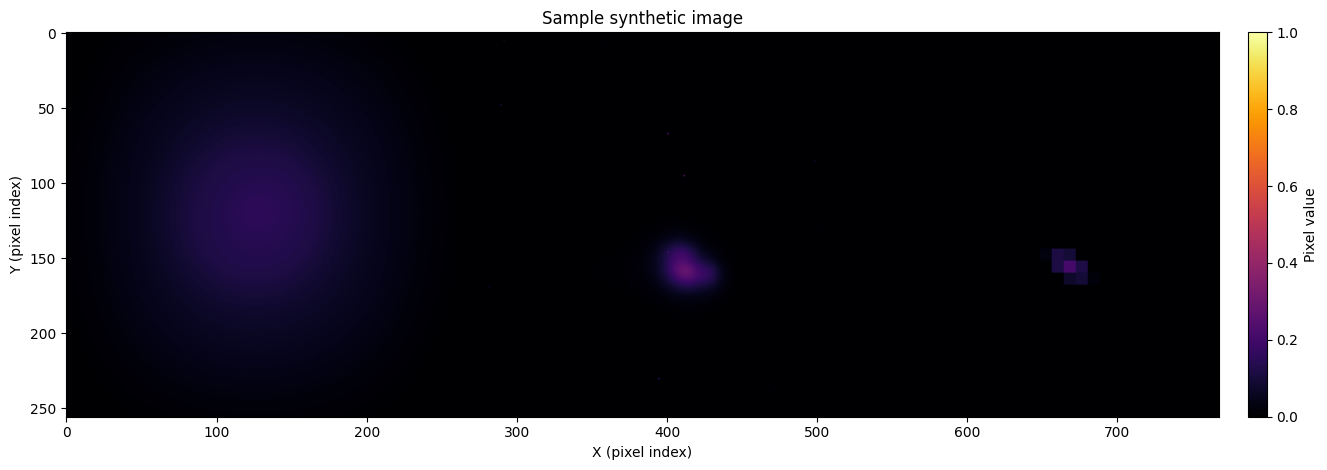

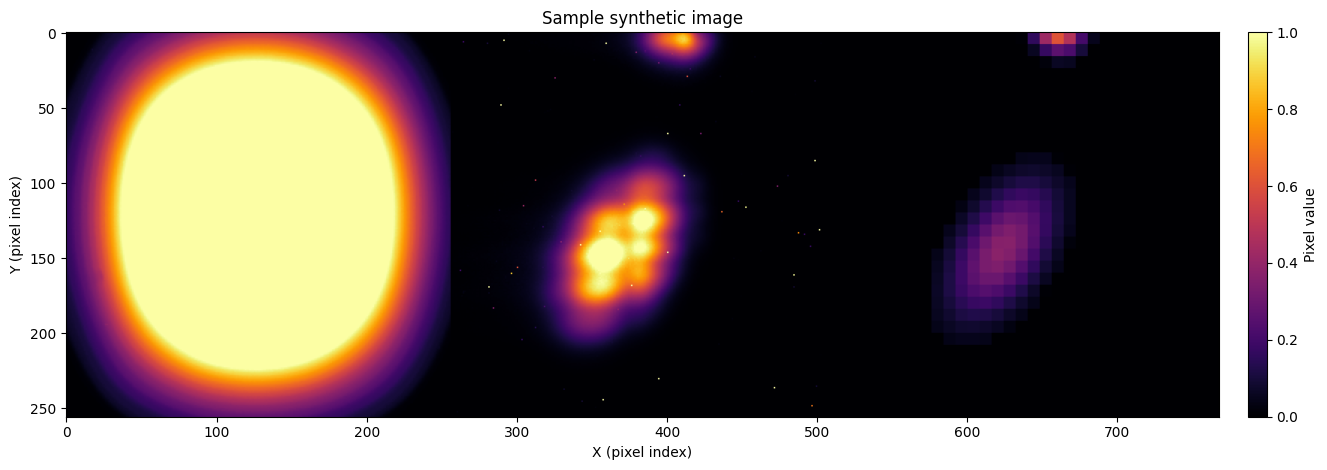

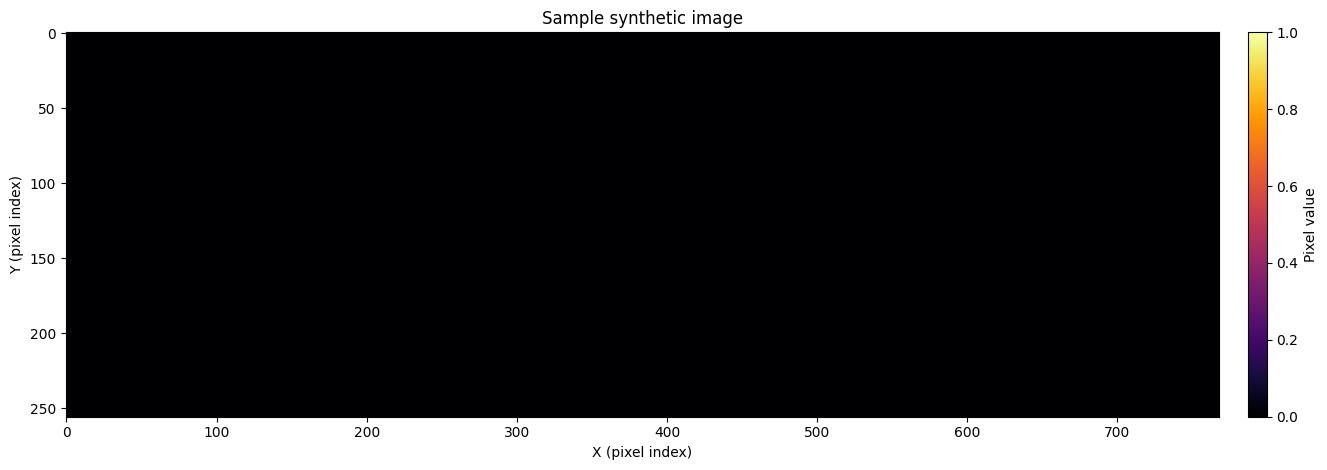

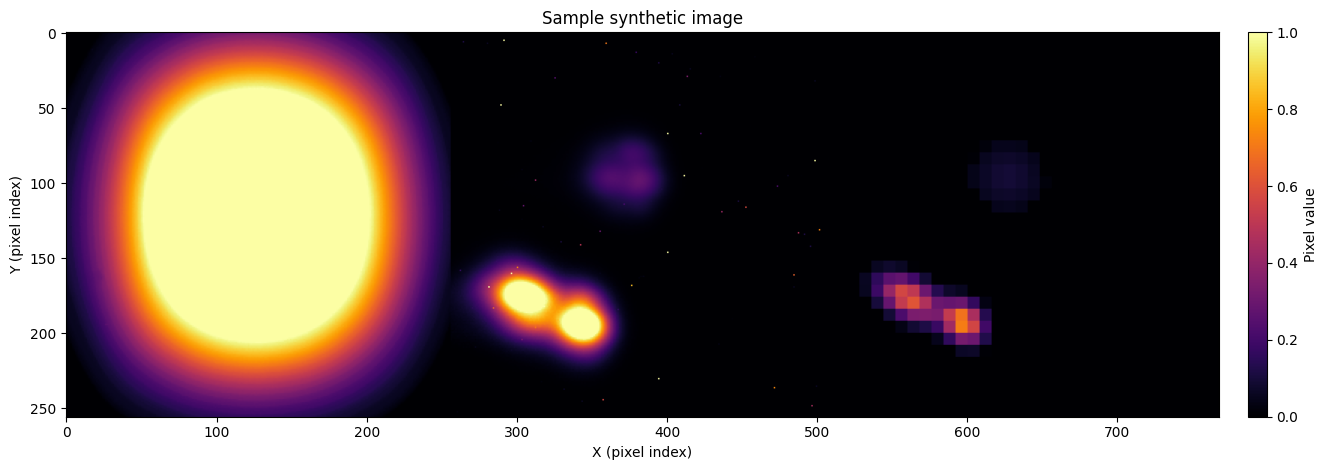

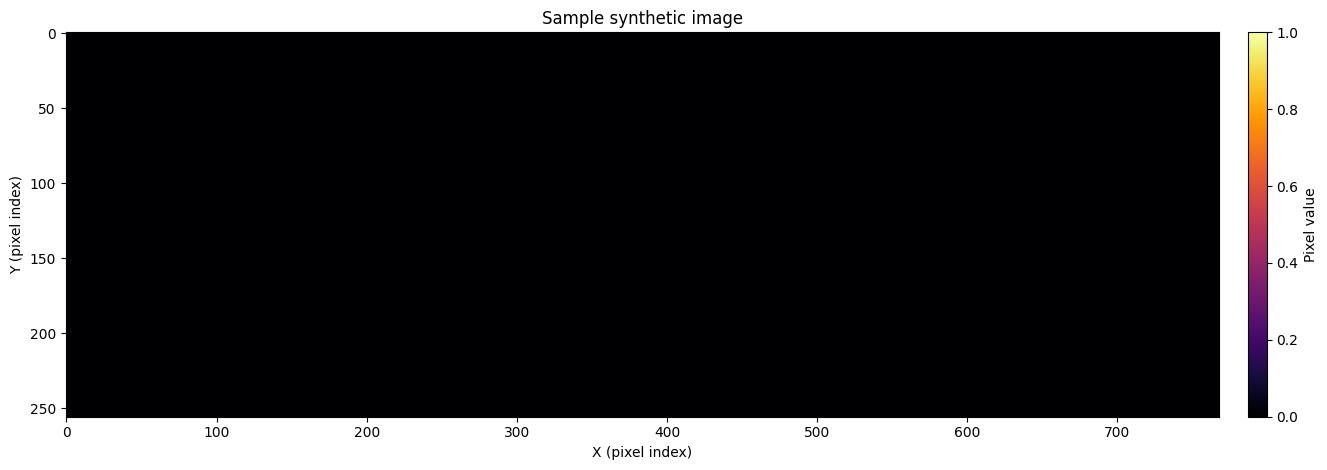

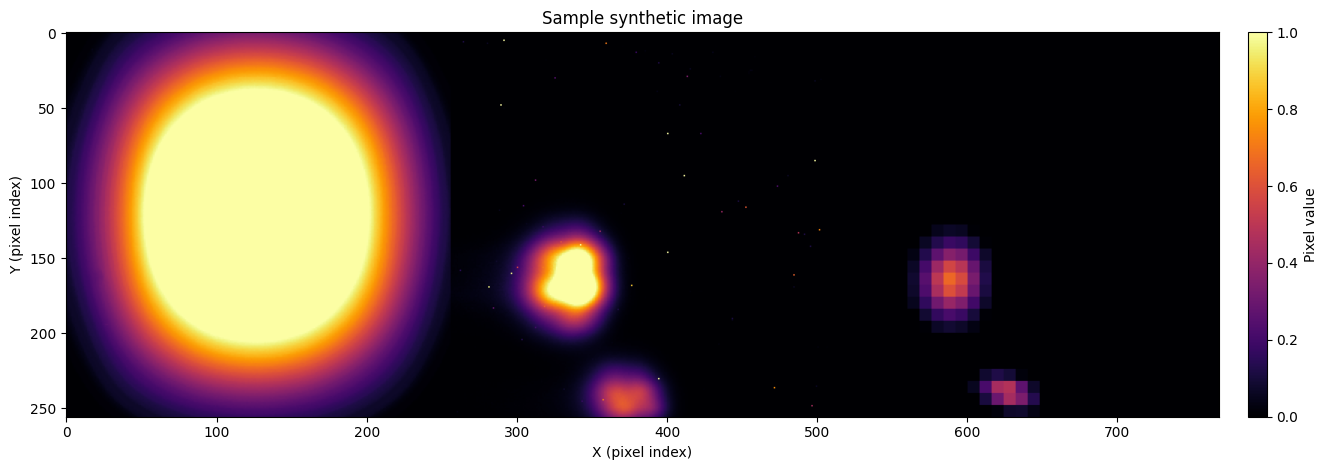

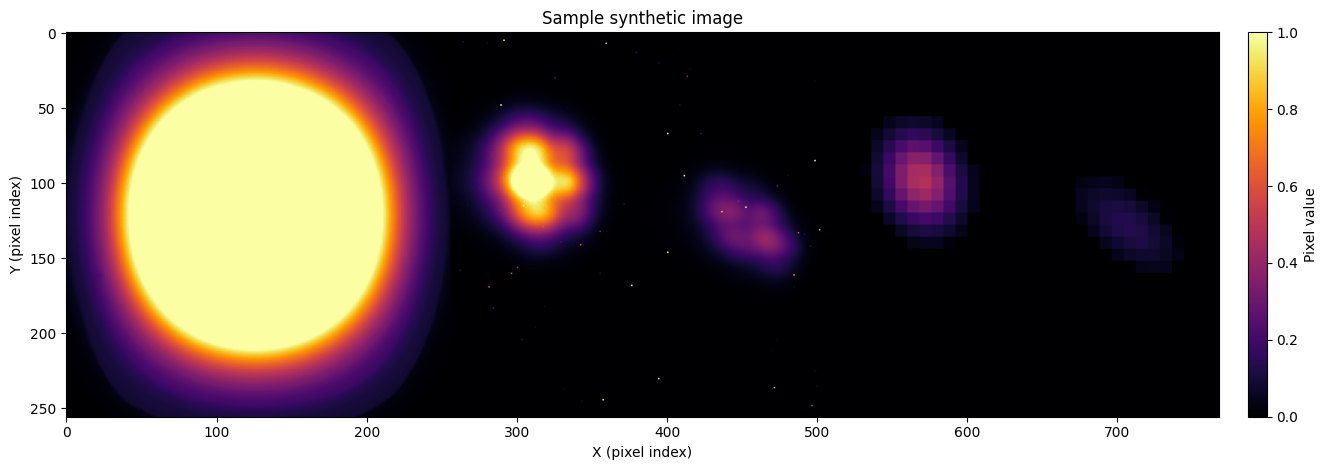

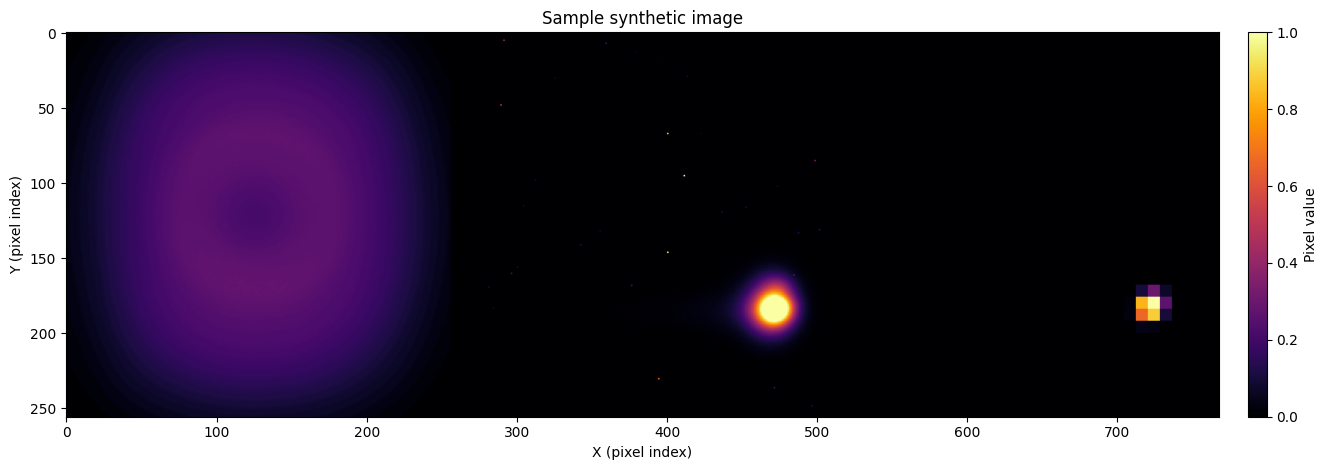

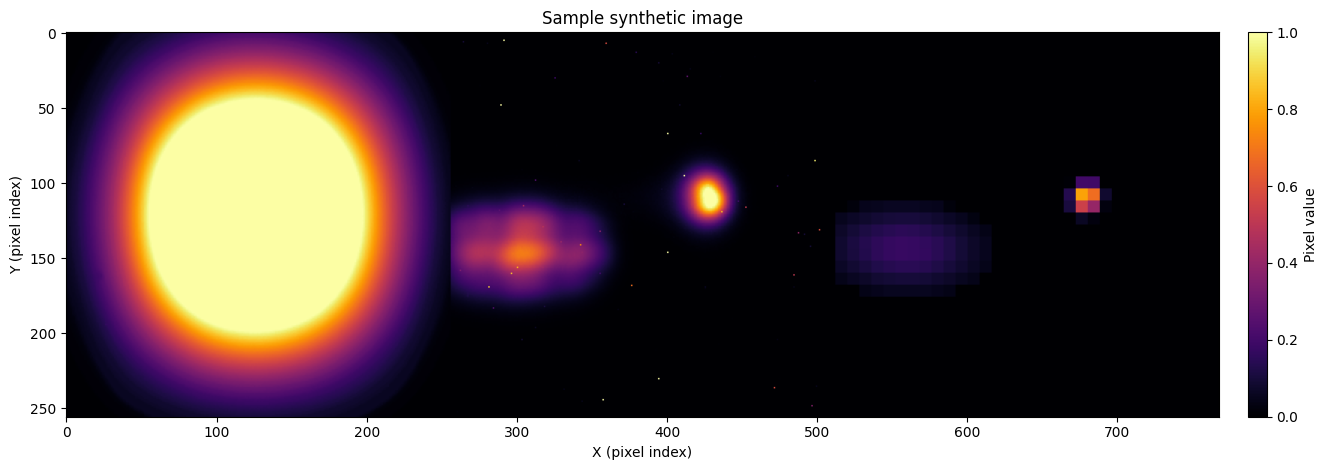

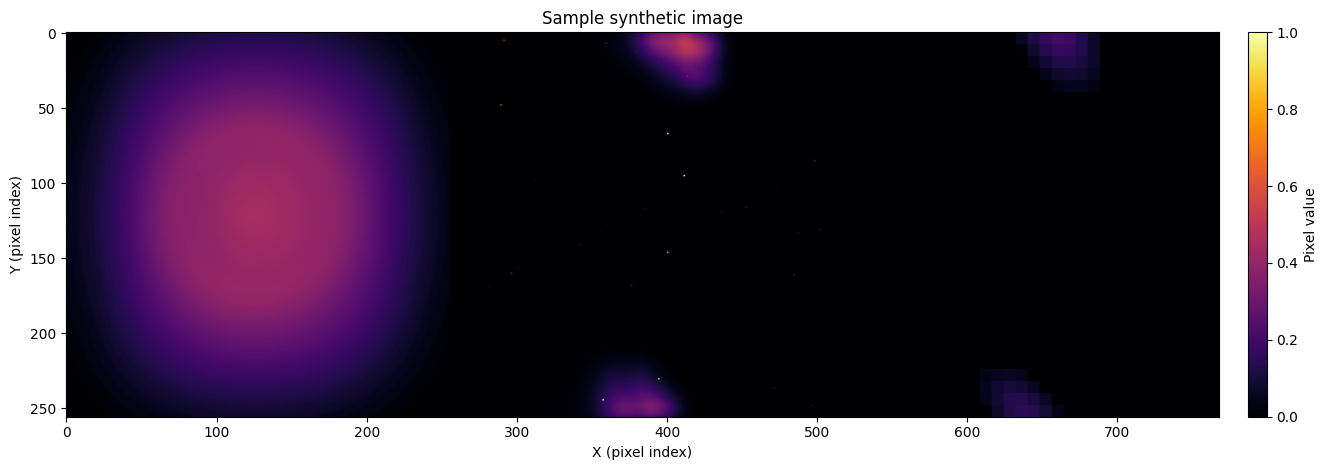

In [10]:
import random

indexs = random.sample(range(1000), 10)
for i in indexs:
    a = samples[0][i]
    b = samples[1][i]
    c = samples[2][i]
    joined_image = T.get("join_image")([a, b, c], layout=(1, 3))
    plot_image(joined_image, title="Sample synthetic image", cmap="inferno", scale="linear", vmin=0, vmax=1)

# Beam settings visualization

In [ ]:
"""
    Based on beam settings (corrector magnets and quads) Check if the parameter increments are correct
    In order to wait magnet (current) until stabilizing, we took 5 images per each setting. 
"""

POSITION = 4  # 0 = 1st in group, 1 = 2nd, ..., 4 = 5th
sql = f"""
WITH ordered AS (
    SELECT
        beam_settings,
        ROW_NUMBER() OVER (ORDER BY image_id) - 1 AS rn
    FROM mmf_dataset_metadata
    WHERE purpose = 'real beam orthogonal acquisition'
      AND comments = 'CLEAR beamtime; 10Hz repetition rate; 15 bunches; ND filter 3; '
      AND is_saturated_ground_truth = 0
      AND CAST(json_extract(camera_config, '$.ground_truth_camera_exposure') AS REAL) = 195000
      AND CAST(json_extract(camera_config, '$.ground_truth_camera_gain') AS INTEGER) = 0
      AND CAST(json_extract(camera_config, '$.speckle_camera_exposure') AS REAL) = 195000
      AND CAST(json_extract(camera_config, '$.speckle_camera_gain') AS INTEGER) = 0
)
SELECT beam_settings
FROM ordered
WHERE rn % 5 = {POSITION};
"""

provider_path = config["paths"]["processed_chromox"]
provider_db_path = provider_path + config["dataset_structure"]["db"]

provider = SqlProvider(
    sources={"connection": provider_db_path, "sql": sql},   
    output_config={'list': "beam_settings"}
)#.subsample(n_samples=10000, seed=config["seed"])


import json
import matplotlib.pyplot as plt
from collections import defaultdict

def plot_magnet_changes(entries, save_prefix=None, show=True):
    """
    entries: iterable of JSON strings like
        '{"CLEAR_magnets": {"QFD0880": 0.058, "QDD0515": 0, "DHJ0840": 7.0, "DVJ0840": -3.6}}'
    Produces one figure per magnet showing its value across the sequence.
    """
    series = defaultdict(list)
    for e in entries:
        d = json.loads(e) if isinstance(e, str) else e
        for name, val in d["CLEAR_magnets"].items():
            series[name].append(val)

    figs = {}
    for name, values in series.items():
        fig, ax = plt.subplots(figsize=(12, 3))
        ax.plot(range(len(values)), values, marker="o", markersize=1, linestyle="none")
        ax.set_title(name)
        ax.set_xlabel("step")
        ax.set_ylabel("magnet current (A)")
        # ax.grid(True, alpha=0.3)
        fig.tight_layout()

        figs[name] = fig

    if show:
        plt.show()
    return figs

print(len(provider()))
plot_magnet_changes(provider(), save_prefix="clear")

# check sql database entries

In [ ]:
import sqlite3
import pandas as pd

sql = """
SELECT
    coupling_ratio,
    CAST(json_extract(REPLACE(ground_truth_stats, char(39), '"'), '$.max')  AS REAL) AS ground_truth_stats_max,
    CAST(json_extract(REPLACE(ground_truth_stats, char(39), '"'), '$.min')  AS REAL) AS ground_truth_stats_min,
    CAST(json_extract(REPLACE(ground_truth_stats, char(39), '"'), '$.mean') AS REAL) AS ground_truth_stats_mean,
    CAST(json_extract(REPLACE(ground_truth_stats, char(39), '"'), '$.sum') AS REAL) AS ground_truth_stats_sum,
    CAST(json_extract(REPLACE(fiber_output_stats, char(39), '"'), '$.max')  AS REAL) AS fiber_output_stats_max,
    CAST(json_extract(REPLACE(fiber_output_stats, char(39), '"'), '$.min')  AS REAL) AS fiber_output_stats_min,
    CAST(json_extract(REPLACE(fiber_output_stats, char(39), '"'), '$.mean') AS REAL) AS fiber_output_stats_mean,
    CAST(json_extract(REPLACE(fiber_output_stats, char(39), '"'), '$.sum') AS REAL) AS fiber_output_stats_sum
FROM mmf_dataset_metadata
WHERE purpose = 'testset'
  AND is_saturated_ground_truth = 0
  AND CAST(json_extract(camera_config, '$.ground_truth_camera_exposure') AS REAL) = 195000
  AND CAST(json_extract(camera_config, '$.ground_truth_camera_gain') AS INTEGER) = 0
  AND CAST(json_extract(camera_config, '$.speckle_camera_exposure') AS REAL) = 195000
  AND CAST(json_extract(camera_config, '$.speckle_camera_gain') AS INTEGER) = 0;
"""

provider_path = config["paths"]["processed_chromox_cropped"]
db_path = provider_path + config["dataset_structure"]["db"]

with sqlite3.connect(db_path) as con:
    df = pd.read_sql_query(sql, con)

result = {col: df[col].tolist() for col in df.columns}
len(result['ground_truth_stats_max'])